# Istanbul Airbnb Analysis — EDA & Hypothesis Tests

**DSA 210 — Spring 2025–2026**  
**Student:** Elif İnce

This notebook performs exploratory data analysis and formal hypothesis testing on the Istanbul Airbnb dataset (Inside Airbnb, September 29, 2025 snapshot). The enriched dataset was created by `src/preprocess.py`.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Plot defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

FIGURES_DIR = os.path.join('..', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(name, fig=None):
    path = os.path.join(FIGURES_DIR, f'{name}.png')
    if fig is not None:
        fig.savefig(path, bbox_inches='tight', facecolor='white')
    else:
        plt.savefig(path, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')

## 1. Load the Enriched Dataset

In [2]:
df = pd.read_csv(os.path.join('..', 'data', 'processed', 'listings_enriched.csv'),
                 low_memory=False)
print(f'Dataset shape: {df.shape}')
print(f'Listings: {len(df):,}')
print(f'Features: {df.shape[1]}')
df.head(3)

Dataset shape: (25206, 81)
Listings: 25,206
Features: 81


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,review_count_computed,first_review_computed,last_review_computed,review_span_days,reviews_per_month_computed
0,1342043490398914341,https://www.airbnb.com/rooms/1342043490398914341,20250929230303,2025-09-30,city scrape,Отдельная квартира на Фатих(Балат).,A cozy apartment in the historical area of Bal...,The apartment is in one of the most atmospheri...,https://a0.muscache.com/pictures/hosting/Hosti...,444141348,...,2,2,0,0,0.58,4.0,2025-03-07,2025-09-19,196.0,0.621224
1,1342082318675744621,https://www.airbnb.com/rooms/1342082318675744621,20250929230303,2025-10-01,city scrape,Blue standart 7,Blue apartments located at perfect point that ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,304448264,...,7,6,1,0,0.67,4.0,2025-04-07,2025-09-02,148.0,0.822703
2,1342210705450176162,https://www.airbnb.com/rooms/1342210705450176162,20250929230303,2025-10-01,city scrape,Central Located Stylish Flat,"Located just 20 meters from Istiklal Street, o...",NaN,https://a0.muscache.com/pictures/airflow/Hosti...,380165223,...,13,13,0,0,3.44,26.0,2025-02-17,2025-08-19,183.0,4.324809


## 2. Dataset Overview

### 2.1 Variable Types

In [3]:
print(df.dtypes.value_counts())

object     32
float64    28
int64      20
bool        1
Name: count, dtype: int64


### 2.2 Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percent', ascending=False)
print(f'Columns with missing values: {len(missing_df)} / {df.shape[1]}')
missing_df.head(20)

Columns with missing values: 43 / 81


,Count,Percent
neighborhood_overview,18352,72.8
neighbourhood,18352,72.8
host_about,14907,59.1
reviews_per_month_computed,11350,45.0
license,10243,40.6
review_scores_rating,9119,36.2
review_scores_accuracy,9121,36.2
review_scores_cleanliness,9119,36.2
review_scores_checkin,9121,36.2
review_scores_communication,9119,36.2


### 2.3 Descriptive Statistics for Key Numeric Features

In [5]:
key_cols = ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
            'minimum_nights', 'maximum_nights',
            'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
            'availability_30', 'availability_60', 'availability_365']
key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].describe().round(2)

,price,accommodates,bedrooms,beds,bathrooms,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,reviews_per_month,availability_30,availability_60,availability_365
count,25206.00,25206.00,25037.00,25160.00,24931.00,25206.00,25206.00,25206.00,16087.00,16087.00,25206.00,25206.00,25206.00
mean,3691.47,3.57,1.50,2.11,1.23,48.68,457.66,19.88,4.60,1.23,22.25,48.46,298.66
std,4901.61,2.20,1.57,2.39,1.00,55.79,303.08,45.15,0.66,1.40,10.17,17.30,92.72
min,80.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.01,0.00,0.00,0.00
25%,1643.00,2.00,1.00,1.00,1.00,2.00,365.00,0.00,4.54,0.21,16.00,43.00,269.00
50%,2535.00,3.00,1.00,1.00,1.00,4.00,365.00,2.00,4.80,0.73,29.00,59.00,352.00
75%,4093.00,4.00,2.00,3.00,1.00,100.00,365.00,18.00,5.00,1.81,30.00,60.00,365.00
max,100000.00,16.00,50.00,67.00,50.00,999.00,9999.00,1653.00,5.00,22.51,30.00,60.00,365.00


## 3. Univariate Distributions

### 3.1 Price Distribution

Saved: ../figures/01_price_distribution.png


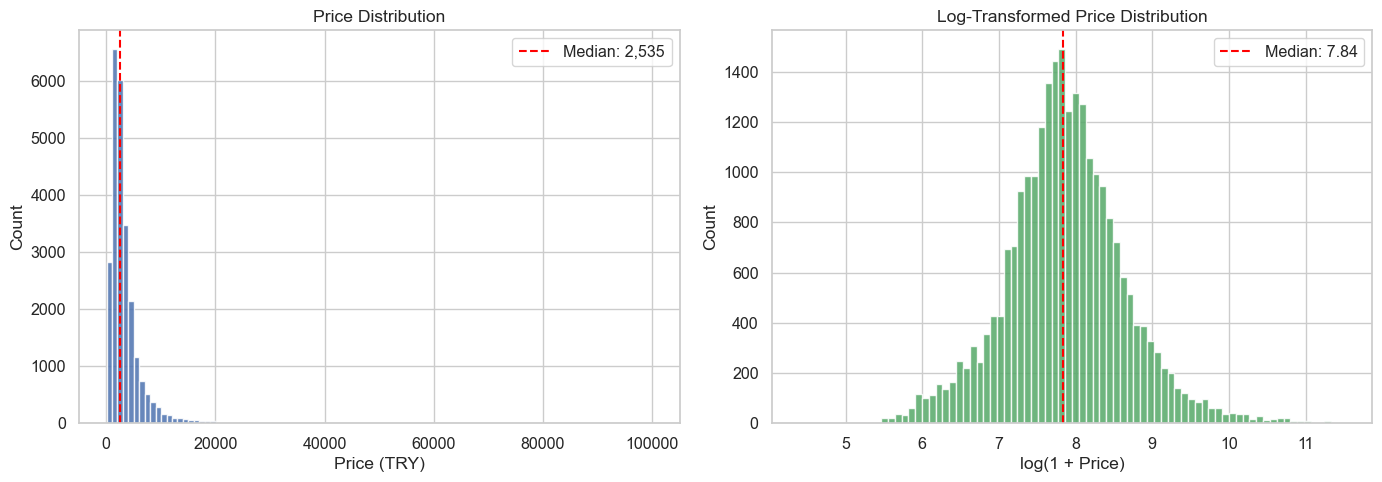


Price summary: mean=3,691, median=2,535, std=4,902, skew=7.85


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=100, edgecolor='white', alpha=0.85, color='#4C72B0')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (TRY)')
axes[0].set_ylabel('Count')
med = df['price'].median()
axes[0].axvline(med, color='red', ls='--', label=f'Median: {med:,.0f}')
axes[0].legend()

df['log_price'] = np.log1p(df['price'])
axes[1].hist(df['log_price'], bins=80, edgecolor='white', alpha=0.85, color='#55A868')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')
med_log = df['log_price'].median()
axes[1].axvline(med_log, color='red', ls='--', label=f'Median: {med_log:.2f}')
axes[1].legend()

plt.tight_layout()
save_fig('01_price_distribution')
plt.show()

print(f"\nPrice summary: mean={df['price'].mean():,.0f}, median={df['price'].median():,.0f}, "
      f"std={df['price'].std():,.0f}, skew={df['price'].skew():.2f}")

### 3.2 Room Type Distribution

Saved: ../figures/02_room_type_distribution.png


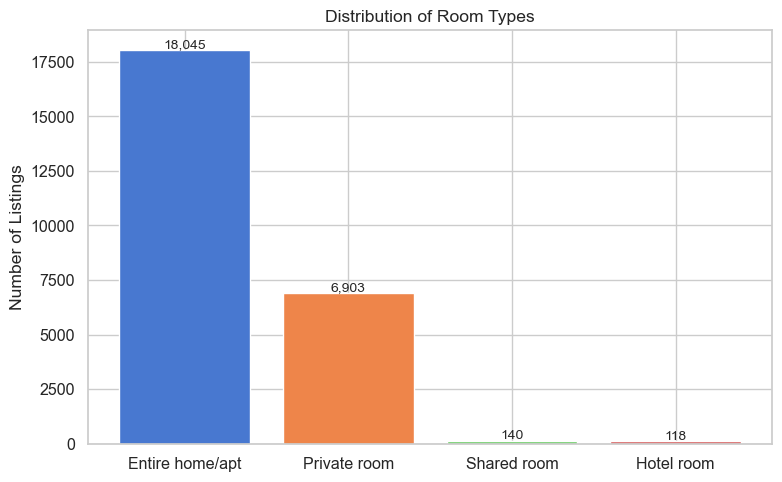

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
room_counts = df['room_type'].value_counts()
colors = sns.color_palette('muted', len(room_counts))
bars = ax.bar(room_counts.index, room_counts.values, color=colors, edgecolor='white')
ax.set_title('Distribution of Room Types')
ax.set_ylabel('Number of Listings')
for bar, count in zip(bars, room_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{count:,}', ha='center', fontsize=10)
plt.tight_layout()
save_fig('02_room_type_distribution')
plt.show()

### 3.3 Top 15 Neighbourhoods

Saved: ../figures/03_top_neighbourhoods.png


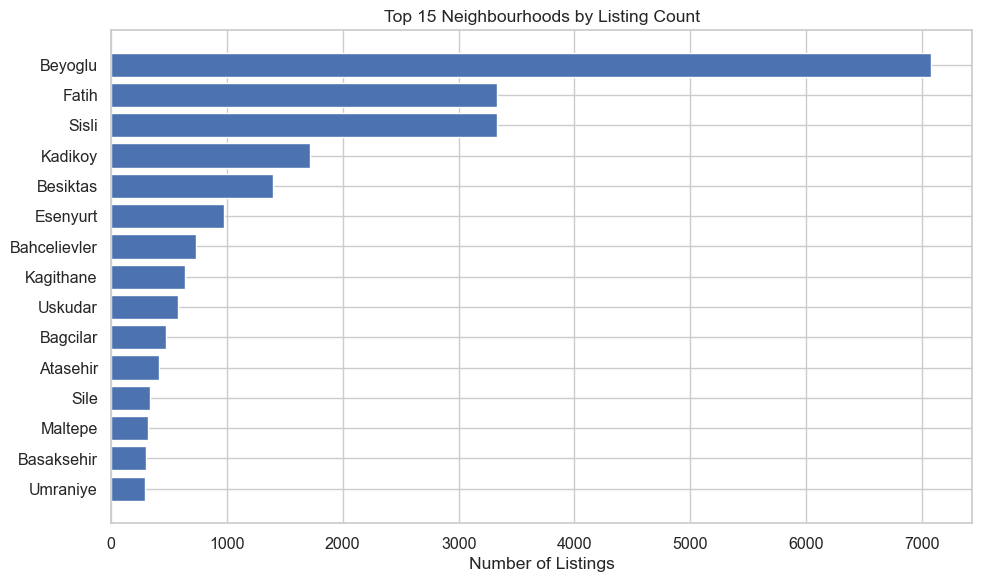

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
top_nbr = df['neighbourhood_cleansed'].value_counts().head(15)
ax.barh(top_nbr.index[::-1], top_nbr.values[::-1], color='#4C72B0', edgecolor='white')
ax.set_title('Top 15 Neighbourhoods by Listing Count')
ax.set_xlabel('Number of Listings')
plt.tight_layout()
save_fig('03_top_neighbourhoods')
plt.show()

### 3.4 Review Score Distributions

Saved: ../figures/04_review_scores.png


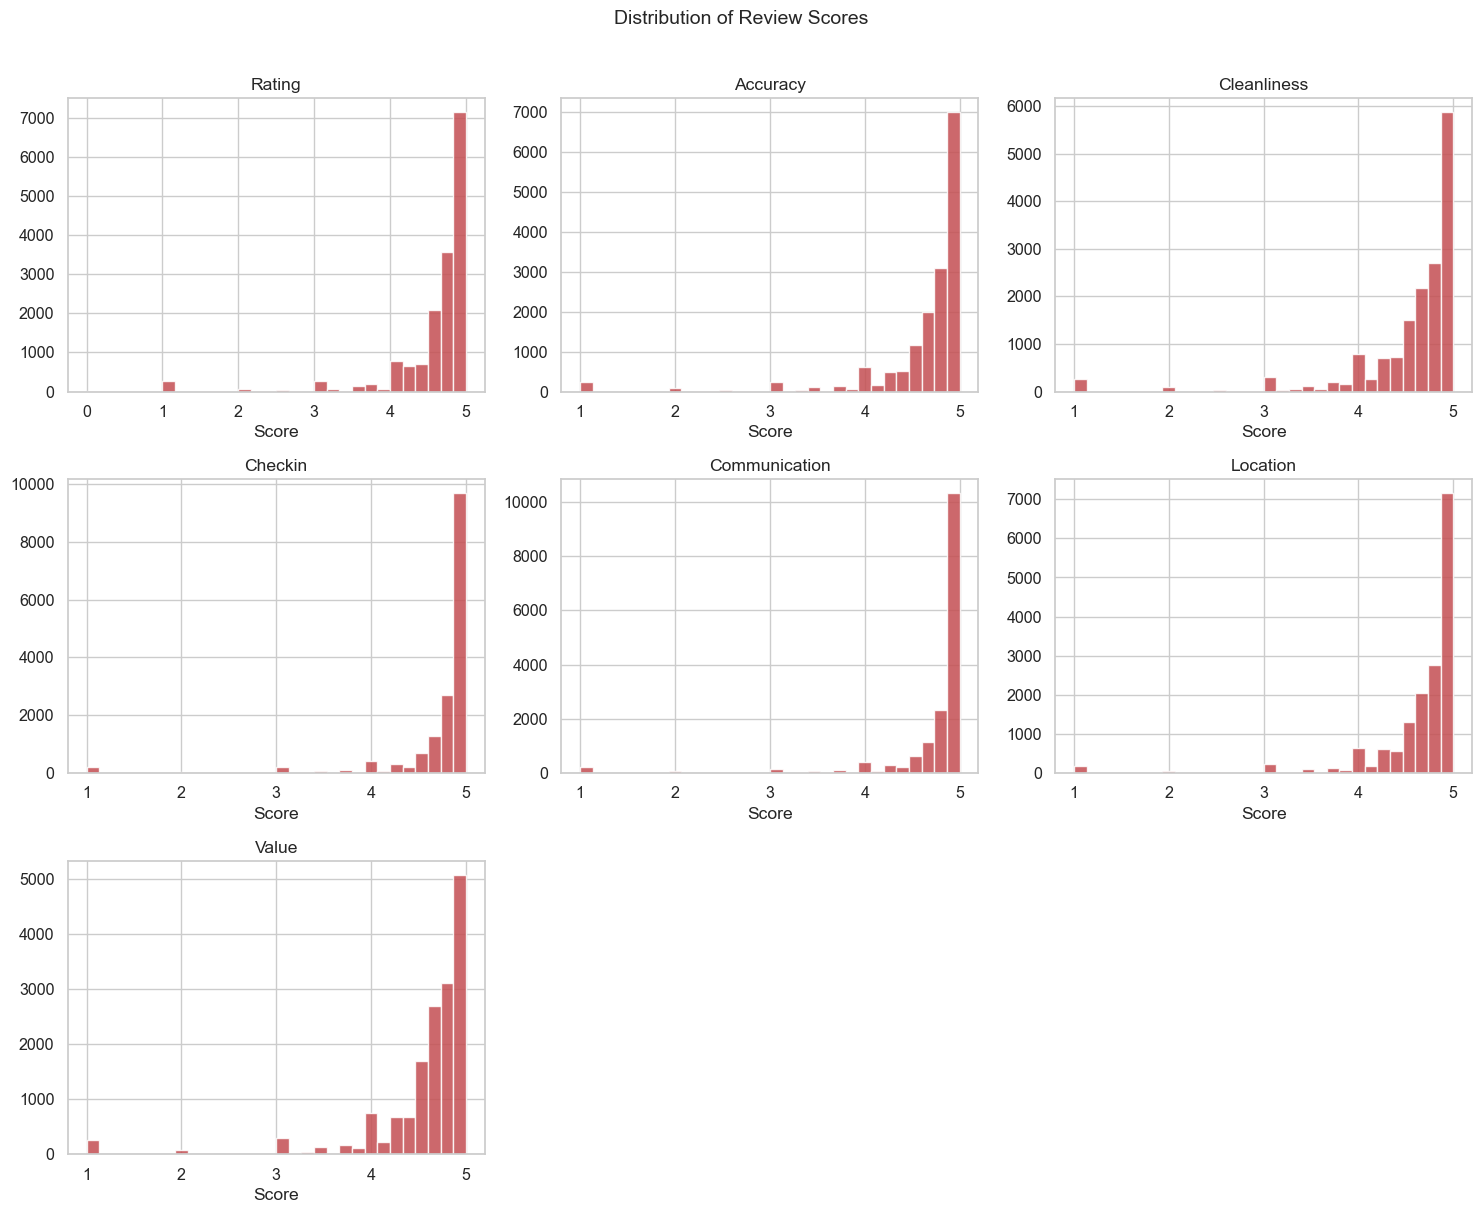

In [9]:
rs_cols = [c for c in df.columns if c.startswith('review_scores_')]
n = len(rs_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()
for i, col in enumerate(rs_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='white', alpha=0.85, color='#C44E52')
    label = col.replace('review_scores_', '').replace('_', ' ').title()
    axes[i].set_title(label)
    axes[i].set_xlabel('Score')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Distribution of Review Scores', fontsize=14, y=1.01)
plt.tight_layout()
save_fig('04_review_scores')
plt.show()

### 3.5 Availability Distribution (365 days)

Saved: ../figures/05_availability_distribution.png


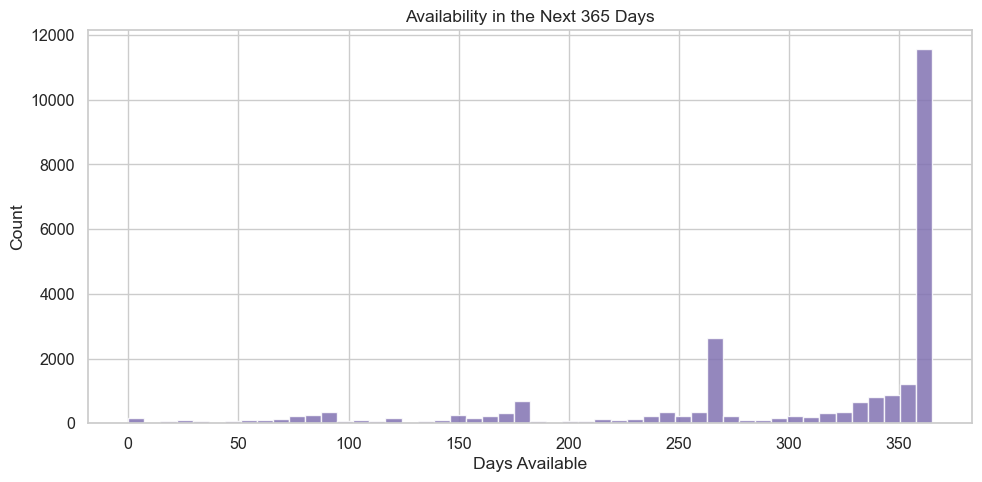

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['availability_365'].dropna(), bins=50, edgecolor='white', alpha=0.85, color='#8172B2')
ax.set_title('Availability in the Next 365 Days')
ax.set_xlabel('Days Available')
ax.set_ylabel('Count')
plt.tight_layout()
save_fig('05_availability_distribution')
plt.show()

## 4. Bivariate Analysis

### 4.1 Price by Room Type

Saved: ../figures/06_price_by_room_type.png


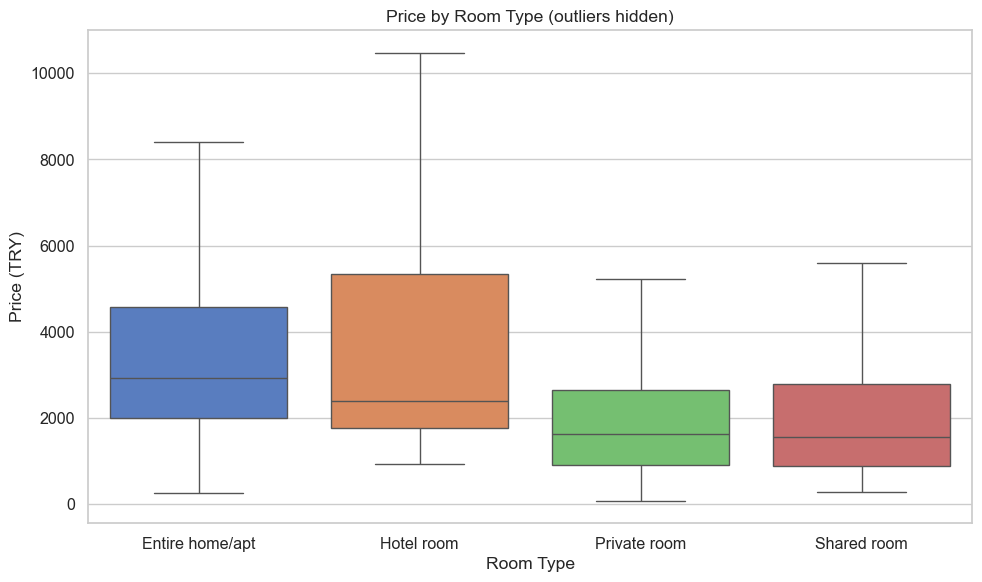

Median price by room type:
room_type
Entire home/apt    2921.0
Hotel room         2404.5
Private room       1618.0
Shared room        1569.5


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
order = df.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='room_type', y='price', order=order, palette='muted',
            showfliers=False, ax=ax)
ax.set_title('Price by Room Type (outliers hidden)')
ax.set_ylabel('Price (TRY)')
ax.set_xlabel('Room Type')
plt.tight_layout()
save_fig('06_price_by_room_type')
plt.show()

print('Median price by room type:')
print(df.groupby('room_type')['price'].median().sort_values(ascending=False).to_string())

### 4.2 Price by Superhost Status

Saved: ../figures/07_price_by_superhost.png


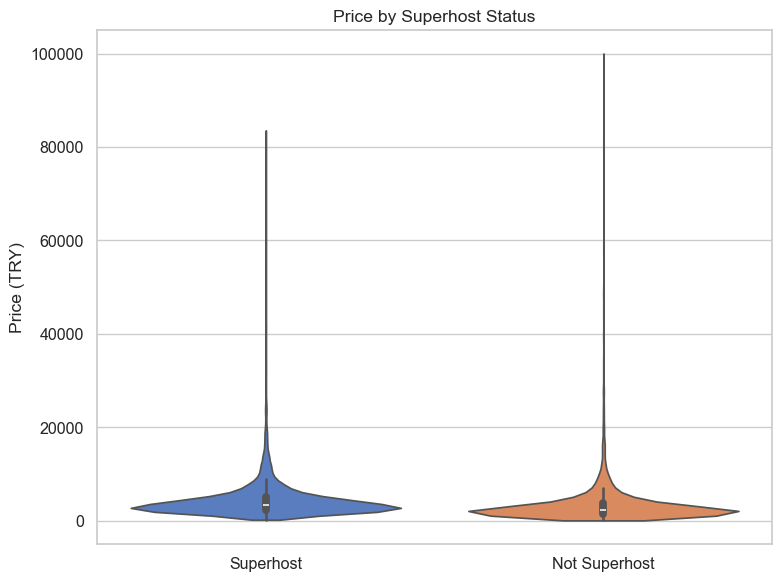

Median price:
superhost_label
Not Superhost    2355.0
Superhost        3380.0


In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
data_sh = df.dropna(subset=['host_is_superhost']).copy()
data_sh['superhost_label'] = data_sh['host_is_superhost'].map({True: 'Superhost', False: 'Not Superhost'})
sns.violinplot(data=data_sh, x='superhost_label', y='price', palette='muted', cut=0, ax=ax)
ax.set_title('Price by Superhost Status')
ax.set_ylabel('Price (TRY)')
ax.set_xlabel('')
plt.tight_layout()
save_fig('07_price_by_superhost')
plt.show()

print('Median price:')
print(data_sh.groupby('superhost_label')['price'].median().to_string())

### 4.3 Price vs. Number of Reviews

Saved: ../figures/08_price_vs_reviews.png


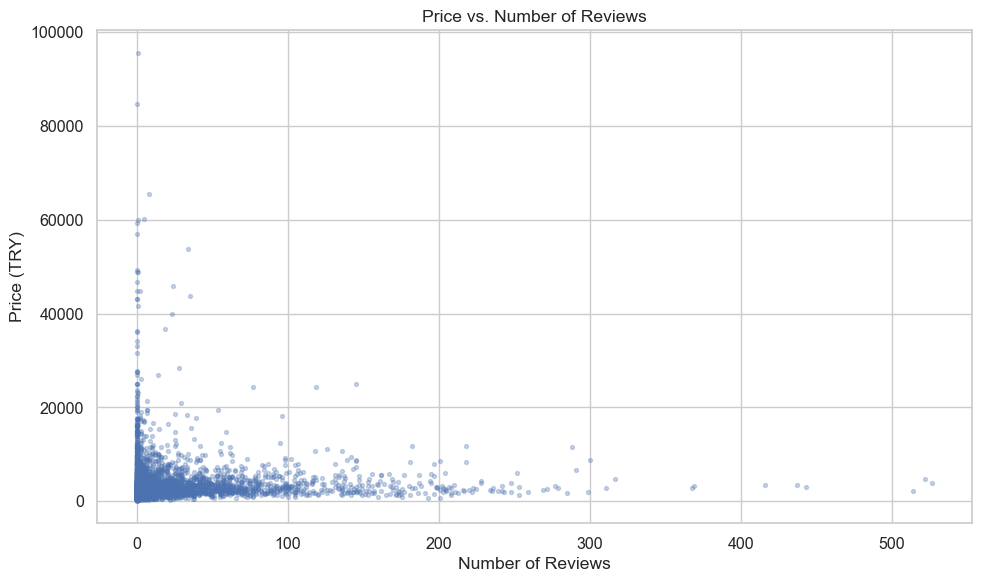

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sample = df.dropna(subset=['number_of_reviews','price']).sample(min(5000, len(df)), random_state=42)
ax.scatter(sample['number_of_reviews'], sample['price'], alpha=0.3, s=8, c='#4C72B0')
ax.set_title('Price vs. Number of Reviews')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Price (TRY)')
plt.tight_layout()
save_fig('08_price_vs_reviews')
plt.show()

### 4.4 Price vs. Review Score Rating

Saved: ../figures/09_price_vs_rating.png


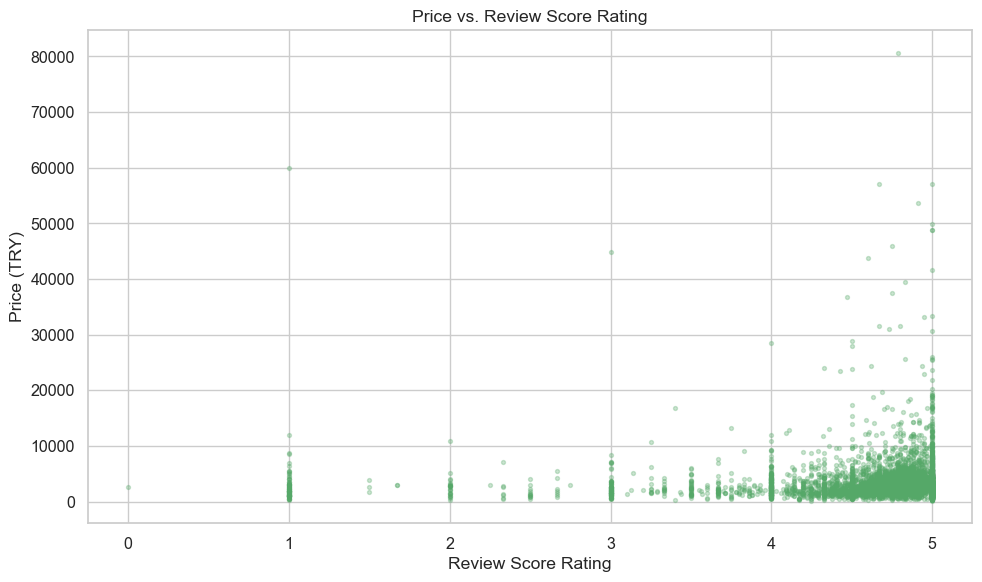

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
data_rs = df.dropna(subset=['review_scores_rating', 'price'])
sample_rs = data_rs.sample(min(5000, len(data_rs)), random_state=42)
ax.scatter(sample_rs['review_scores_rating'], sample_rs['price'], alpha=0.3, s=8, c='#55A868')
ax.set_title('Price vs. Review Score Rating')
ax.set_xlabel('Review Score Rating')
ax.set_ylabel('Price (TRY)')
plt.tight_layout()
save_fig('09_price_vs_rating')
plt.show()

### 4.5 Correlation Heatmap

Saved: ../figures/10_correlation_heatmap.png


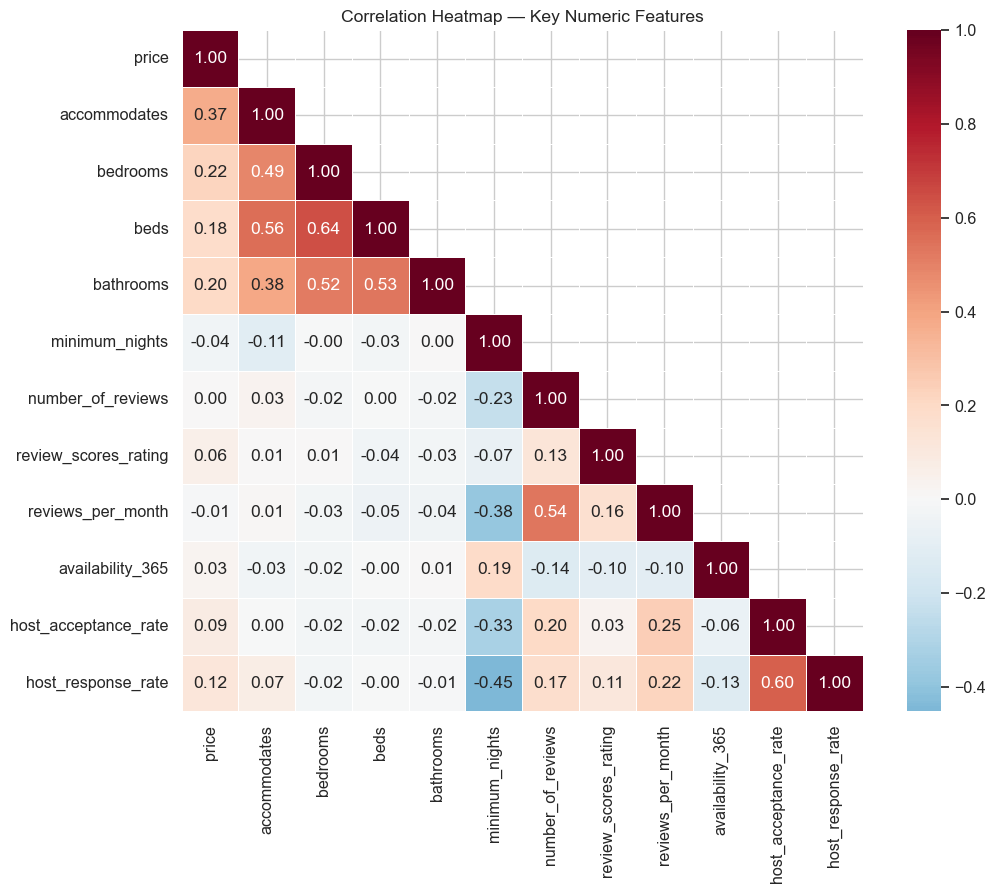

In [15]:
corr_cols = [c for c in ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
             'minimum_nights', 'number_of_reviews', 'review_scores_rating',
             'reviews_per_month', 'availability_365', 'host_acceptance_rate',
             'host_response_rate'] if c in df.columns]
corr_matrix = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Key Numeric Features')
plt.tight_layout()
save_fig('10_correlation_heatmap')
plt.show()

### 4.6 Price by Top 10 Neighbourhoods

Saved: ../figures/11_price_by_neighbourhood.png


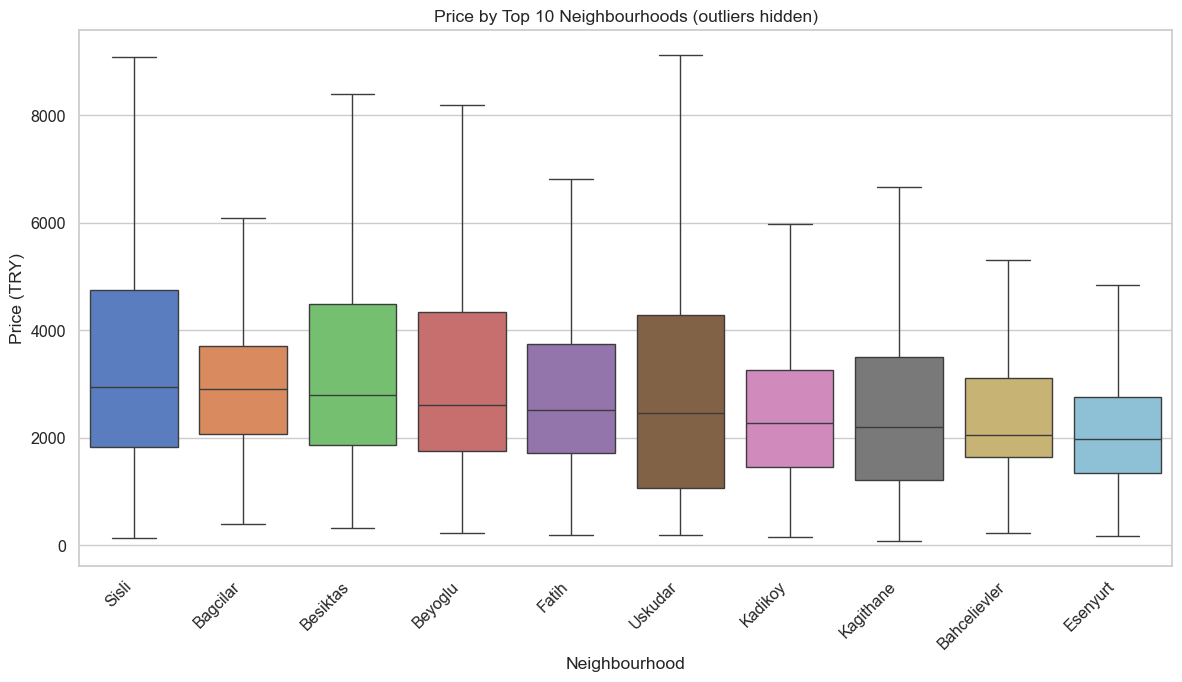

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))
top10 = df['neighbourhood_cleansed'].value_counts().head(10).index
df_top10 = df[df['neighbourhood_cleansed'].isin(top10)]
order_n = df_top10.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top10, x='neighbourhood_cleansed', y='price', order=order_n,
            palette='muted', showfliers=False, ax=ax)
ax.set_title('Price by Top 10 Neighbourhoods (outliers hidden)')
ax.set_ylabel('Price (TRY)')
ax.set_xlabel('Neighbourhood')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_fig('11_price_by_neighbourhood')
plt.show()

### 4.7 Availability by Room Type

Saved: ../figures/12_availability_by_room_type.png


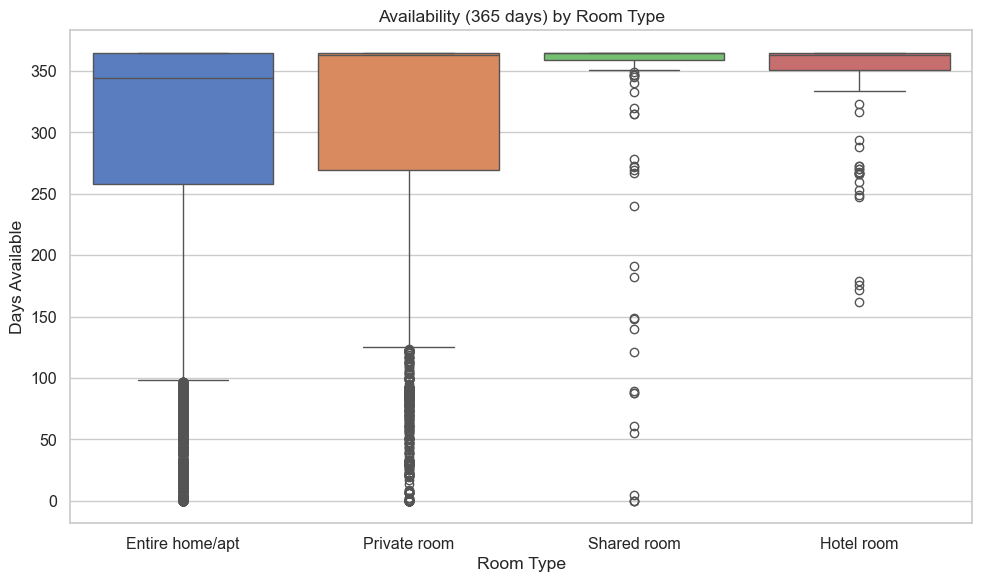

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='room_type', y='availability_365', palette='muted', ax=ax)
ax.set_title('Availability (365 days) by Room Type')
ax.set_ylabel('Days Available')
ax.set_xlabel('Room Type')
plt.tight_layout()
save_fig('12_availability_by_room_type')
plt.show()

### 4.8 Listing Locations (Latitude/Longitude)

Saved: ../figures/13_location_scatter.png


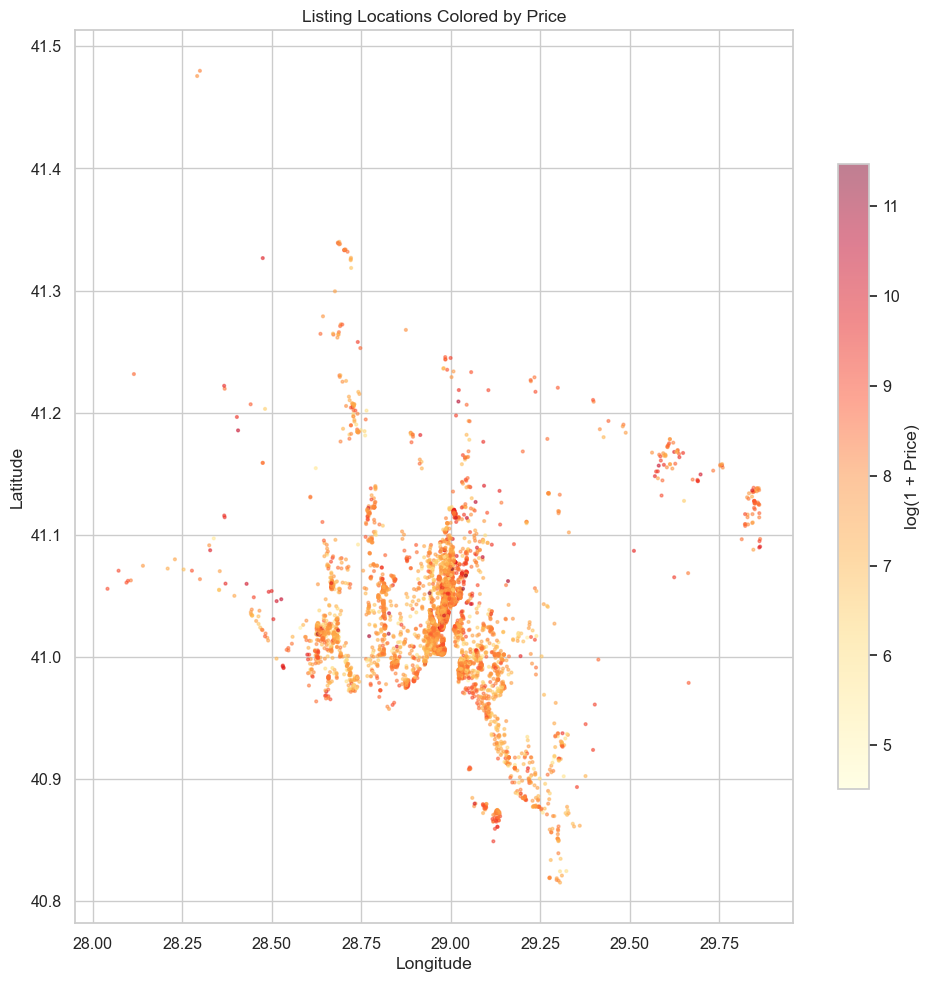

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))
loc = df.dropna(subset=['latitude','longitude'])
sample_loc = loc.sample(min(8000, len(loc)), random_state=42)
sc = ax.scatter(sample_loc['longitude'], sample_loc['latitude'],
                c=np.log1p(sample_loc['price']), cmap='YlOrRd', alpha=0.5, s=4)
plt.colorbar(sc, label='log(1 + Price)', shrink=0.7)
ax.set_title('Listing Locations Colored by Price')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
save_fig('13_location_scatter')
plt.show()

## 5. Hypothesis Tests

For each research question, we first inspect the relevant distributions and check assumptions (especially normality), then choose the most appropriate statistical test from the course material. Since Airbnb prices are typically right-skewed, we expect to rely on non-parametric tests in most cases.

**Significance level**: α = 0.05 for all tests.

### Test 1: Does price differ across room types?

We compare the distributions of listing price across room types (Entire home/apt, Private room, Shared room, Hotel room). Since there are more than two groups, we consider one-way ANOVA or Kruskal-Wallis. We first check normality within each group.

In [19]:
# Assumption check: normality within each room type
room_types = df['room_type'].unique()
print('Shapiro-Wilk normality test (sample per group):')
for rt in room_types:
    prices = df[df['room_type'] == rt]['price'].dropna()
    sample = prices.sample(min(5000, len(prices)), random_state=42)
    stat, p = stats.shapiro(sample)
    print(f'  {rt}: W={stat:.4f}, p={p:.2e}  (n={len(prices):,})')

print()
print('All groups strongly reject normality (p ≈ 0).')
print('→ Using Kruskal-Wallis H test (non-parametric alternative to one-way ANOVA).')

Shapiro-Wilk normality test (sample per group):
  Entire home/apt: W=0.4752, p=3.37e-81  (n=18,045)
  Private room: W=0.3749, p=4.73e-85  (n=6,903)
  Shared room: W=0.9015, p=3.82e-08  (n=140)
  Hotel room: W=0.6018, p=2.16e-16  (n=118)

All groups strongly reject normality (p ≈ 0).
→ Using Kruskal-Wallis H test (non-parametric alternative to one-way ANOVA).


In [20]:
# Kruskal-Wallis H Test
# H0: The price distributions are the same across all room types.
# H1: At least one room type has a different price distribution.

groups = [g['price'].dropna().values for _, g in df.groupby('room_type')]
stat, p_value = stats.kruskal(*groups)

print('--- Kruskal-Wallis H Test: Price ~ Room Type ---')
print(f'H statistic: {stat:.2f}')
print(f'P-value:     {p_value:.2e}')

# Effect size: eta-squared approximation
n = sum(len(g) for g in groups)
k = len(groups)
eta_sq = (stat - k + 1) / (n - k)
print(f'Effect size (η²): {eta_sq:.4f}')
print()

alpha = 0.05
if p_value < alpha:
    print(f'Conclusion: p < {alpha} → Reject H0.')
    print('There is a statistically significant difference in price across room types.')
else:
    print(f'Conclusion: p ≥ {alpha} → Fail to reject H0.')

print()
print('Median price by room type:')
for rt in df.groupby('room_type')['price'].median().sort_values(ascending=False).items():
    print(f'  {rt[0]}: {rt[1]:,.0f} TRY')

--- Kruskal-Wallis H Test: Price ~ Room Type ---
H statistic: 3584.86
P-value:     0.00e+00
Effect size (η²): 0.1421

Conclusion: p < 0.05 → Reject H0.
There is a statistically significant difference in price across room types.

Median price by room type:
  Entire home/apt: 2,921 TRY
  Hotel room: 2,404 TRY
  Private room: 1,618 TRY
  Shared room: 1,570 TRY


### Test 2: Do superhosts differ from non-superhosts in price?

This is a two-group comparison. We consider Welch's t-test (parametric) vs. Mann-Whitney U (non-parametric). We check normality first.

In [21]:
superhost = df[df['host_is_superhost'] == True]['price'].dropna()
non_superhost = df[df['host_is_superhost'] == False]['price'].dropna()
print(f'Superhosts:     {len(superhost):,} listings')
print(f'Non-superhosts: {len(non_superhost):,} listings')
print()

for label, data in [('Superhost', superhost), ('Non-superhost', non_superhost)]:
    s = data.sample(min(5000, len(data)), random_state=42)
    w, p = stats.shapiro(s)
    print(f'{label} Shapiro-Wilk: W={w:.4f}, p={p:.2e}')

print()
print('Both groups fail normality → Using Mann-Whitney U test.')

Superhosts:     5,221 listings
Non-superhosts: 19,272 listings

Superhost Shapiro-Wilk: W=0.6100, p=7.19e-75
Non-superhost Shapiro-Wilk: W=0.4618, p=9.47e-82

Both groups fail normality → Using Mann-Whitney U test.


In [22]:
# Mann-Whitney U Test
# H0: The price distributions of superhost and non-superhost listings are the same.
# H1: The price distributions differ between the two groups.

stat, p_value = stats.mannwhitneyu(superhost, non_superhost, alternative='two-sided')

print('--- Mann-Whitney U Test: Price ~ Superhost Status ---')
print(f'U statistic: {stat:,.0f}')
print(f'P-value:     {p_value:.2e}')

# Effect size: rank-biserial correlation
n1, n2 = len(superhost), len(non_superhost)
r_rb = 1 - (2 * stat) / (n1 * n2)
print(f'Effect size (rank-biserial r): {r_rb:.4f}')
print()

alpha = 0.05
if p_value < alpha:
    print(f'Conclusion: p < {alpha} → Reject H0.')
    print('Superhost and non-superhost listings differ significantly in price.')
else:
    print(f'Conclusion: p ≥ {alpha} → Fail to reject H0.')

print(f'\nMedian — Superhosts: {superhost.median():,.0f} TRY')
print(f'Median — Non-superhosts: {non_superhost.median():,.0f} TRY')

--- Mann-Whitney U Test: Price ~ Superhost Status ---
U statistic: 66,566,510
P-value:     8.24e-282
Effect size (rank-biserial r): -0.3231

Conclusion: p < 0.05 → Reject H0.
Superhost and non-superhost listings differ significantly in price.

Median — Superhosts: 3,380 TRY
Median — Non-superhosts: 2,355 TRY


### Test 3: Is listing price associated with review score rating?

We test whether there is a monotonic association between price and review score rating. We check linearity to decide between Pearson and Spearman correlation.

Listings with both values: 16,087


Saved: ../figures/14_ht3_linearity.png


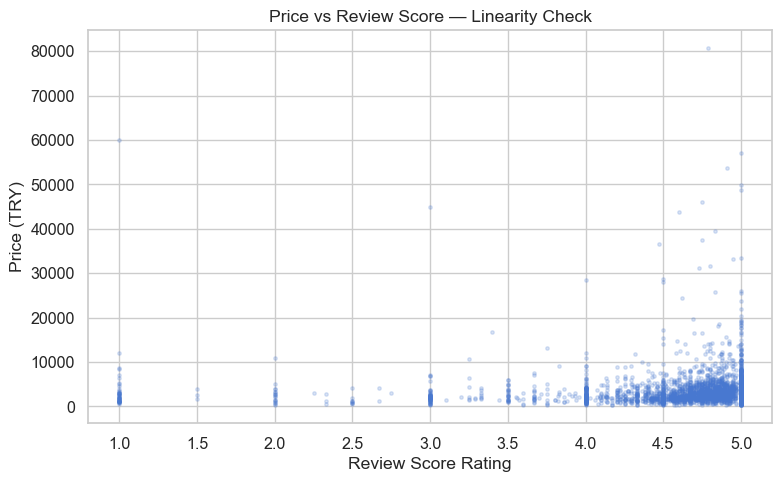

The relationship is not clearly linear → Using Spearman rank correlation.


In [23]:
data_corr = df[['price', 'review_scores_rating']].dropna()
print(f'Listings with both values: {len(data_corr):,}')

fig, ax = plt.subplots(figsize=(8, 5))
s = data_corr.sample(min(3000, len(data_corr)), random_state=42)
ax.scatter(s['review_scores_rating'], s['price'], alpha=0.2, s=6)
ax.set_xlabel('Review Score Rating')
ax.set_ylabel('Price (TRY)')
ax.set_title('Price vs Review Score — Linearity Check')
plt.tight_layout()
save_fig('14_ht3_linearity')
plt.show()

print('The relationship is not clearly linear → Using Spearman rank correlation.')

In [24]:
# Spearman Rank Correlation
# H0: There is no monotonic association between price and review score rating (ρ = 0).
# H1: There is a significant monotonic association (ρ ≠ 0).

rho, p_value = stats.spearmanr(data_corr['price'], data_corr['review_scores_rating'])

print('--- Spearman Rank Correlation: Price ~ Review Score Rating ---')
print(f'Spearman ρ: {rho:.4f}')
print(f'P-value:    {p_value:.2e}')
print()

alpha = 0.05
if p_value < alpha:
    direction = 'positive' if rho > 0 else 'negative'
    print(f'Conclusion: p < {alpha} → Reject H0.')
    print(f'There is a statistically significant, weak {direction} monotonic association')
    print(f'between price and review score rating (ρ = {rho:.4f}).')
else:
    print(f'Conclusion: p ≥ {alpha} → Fail to reject H0.')

# Pearson for comparison
r_p, p_p = stats.pearsonr(data_corr['price'], data_corr['review_scores_rating'])
print(f'\nFor comparison — Pearson r = {r_p:.4f}, p = {p_p:.2e}')

--- Spearman Rank Correlation: Price ~ Review Score Rating ---
Spearman ρ: 0.1476
P-value:    5.47e-79

Conclusion: p < 0.05 → Reject H0.
There is a statistically significant, weak positive monotonic association
between price and review score rating (ρ = 0.1476).

For comparison — Pearson r = 0.0563, p = 8.58e-13


### Test 4: Is availability level associated with room type?

We categorize availability into Low / Medium / High and test whether the distribution across these categories is independent of room type using the chi-square test of independence.

In [25]:
# Create availability categories
df['avail_category'] = pd.cut(
    df['availability_365'],
    bins=[-1, 30, 180, 365],
    labels=['Low (0–30)', 'Medium (31–180)', 'High (181–365)']
)

ct = pd.crosstab(df['room_type'], df['avail_category'])
print('Contingency Table:')
print(ct)
print()

# Check assumption: expected frequencies ≥ 5
chi2, p_value, dof, expected = stats.chi2_contingency(ct)
min_exp = expected.min()
print(f'Minimum expected frequency: {min_exp:.1f}')
if min_exp >= 5:
    print('All expected frequencies ≥ 5 → Chi-square test is appropriate.')
else:
    print('Some expected frequencies < 5 → interpret with caution.')

Contingency Table:
avail_category   Low (0–30)  Medium (31–180)  High (181–365)
room_type                                                   
Entire home/apt         301             2882           14862
Hotel room                0                4             114
Private room             93              669            6141
Shared room               4                9             127

Minimum expected frequency: 1.9
Some expected frequencies < 5 → interpret with caution.


In [26]:
# Chi-Square Test of Independence
# H0: Room type and availability level are independent.
# H1: Room type and availability level are NOT independent.

print('--- Chi-Square Test: Room Type × Availability Level ---')
print(f'χ² statistic: {chi2:.2f}')
print(f'Degrees of freedom: {dof}')
print(f'P-value: {p_value:.2e}')

# Cramér's V
n_obs = ct.values.sum()
min_dim = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n_obs * min_dim))
print(f"Cramér's V: {cramers_v:.4f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f'Conclusion: p < {alpha} → Reject H0.')
    print('Room type and availability level are significantly associated.')
else:
    print(f'Conclusion: p ≥ {alpha} → Fail to reject H0.')

print()
print('Row proportions (% within each room type):')
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

--- Chi-Square Test: Room Type × Availability Level ---
χ² statistic: 190.16
Degrees of freedom: 6
P-value: 2.35e-38
Cramér's V: 0.0614

Conclusion: p < 0.05 → Reject H0.
Room type and availability level are significantly associated.

Row proportions (% within each room type):
avail_category   Low (0–30)  Medium (31–180)  High (181–365)
room_type                                                   
Entire home/apt         1.7             16.0            82.4
Hotel room              0.0              3.4            96.6
Private room            1.3              9.7            89.0
Shared room             2.9              6.4            90.7


### Test 5: Do prices differ across major Istanbul neighbourhoods?

We compare price distributions across the top 10 neighbourhoods by listing count. With more than two groups and expected non-normality, we again consider Kruskal-Wallis.

In [27]:
top_n = 10
top_neighbourhoods = df['neighbourhood_cleansed'].value_counts().head(top_n).index.tolist()
df_topn = df[df['neighbourhood_cleansed'].isin(top_neighbourhoods)]
print(f'Top {top_n} neighbourhoods: {len(df_topn):,} listings')
print()

# Quick normality check
print('Shapiro-Wilk tests (first 5 neighbourhoods):')
for nbr in top_neighbourhoods[:5]:
    prices = df_topn[df_topn['neighbourhood_cleansed'] == nbr]['price'].dropna()
    sample = prices.sample(min(5000, len(prices)), random_state=42)
    w, p = stats.shapiro(sample)
    print(f'  {nbr}: W={w:.4f}, p={p:.2e}')

print()
print('Distributions are non-normal → Using Kruskal-Wallis H test.')

Top 10 neighbourhoods: 20,263 listings

Shapiro-Wilk tests (first 5 neighbourhoods):
  Beyoglu: W=0.4343, p=7.71e-83
  Fatih: W=0.4954, p=7.52e-71
  Sisli: W=0.5786, p=2.74e-67
  Kadikoy: W=0.6699, p=1.48e-49
  Besiktas: W=0.3661, p=1.62e-56

Distributions are non-normal → Using Kruskal-Wallis H test.


In [28]:
# Kruskal-Wallis H Test
# H0: The price distributions are the same across all top neighbourhoods.
# H1: At least one neighbourhood has a different price distribution.

groups_nbr = [g['price'].dropna().values for _, g in df_topn.groupby('neighbourhood_cleansed')]
stat, p_value = stats.kruskal(*groups_nbr)

print('--- Kruskal-Wallis H Test: Price ~ Neighbourhood ---')
print(f'H statistic: {stat:.2f}')
print(f'P-value:     {p_value:.2e}')

n = sum(len(g) for g in groups_nbr)
k = len(groups_nbr)
eta_sq = (stat - k + 1) / (n - k)
print(f'Effect size (η²): {eta_sq:.4f}')
print()

alpha = 0.05
if p_value < alpha:
    print(f'Conclusion: p < {alpha} → Reject H0.')
    print('There is a statistically significant difference in price across neighbourhoods.')
else:
    print(f'Conclusion: p ≥ {alpha} → Fail to reject H0.')

print()
print('Median price by neighbourhood (sorted):')
medians = df_topn.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False)
for nbr, med in medians.items():
    print(f'  {nbr}: {med:,.0f} TRY')

--- Kruskal-Wallis H Test: Price ~ Neighbourhood ---
H statistic: 625.57
P-value:     6.80e-129
Effect size (η²): 0.0304

Conclusion: p < 0.05 → Reject H0.
There is a statistically significant difference in price across neighbourhoods.

Median price by neighbourhood (sorted):
  Sisli: 2,940 TRY
  Bagcilar: 2,911 TRY
  Besiktas: 2,804 TRY
  Beyoglu: 2,621 TRY
  Fatih: 2,518 TRY
  Uskudar: 2,466 TRY
  Kadikoy: 2,276 TRY
  Kagithane: 2,200 TRY
  Bahcelievler: 2,059 TRY
  Esenyurt: 1,976 TRY


## 6. Summary

### EDA Key Findings

- **Price** is heavily right-skewed; a log transformation yields a more symmetric distribution.
- **Entire home/apt** is the most common room type and has the highest median price.
- Listings are concentrated in central neighbourhoods such as Beyoğlu, Fatih, and Şişli.
- Price is positively correlated with capacity features (accommodates, bedrooms, beds, bathrooms).
- Availability patterns vary by room type.

### Hypothesis Test Results

| # | Question | Test | Key Result |
|---|----------|------|------------|
| 1 | Price ~ Room Type | Kruskal-Wallis | Significant difference |
| 2 | Price ~ Superhost | Mann-Whitney U | Significant difference; superhost listings have a higher median price |
| 3 | Price ~ Review Score | Spearman rho | Significant but weak positive association |
| 4 | Room Type x Availability | Chi-Square | Significant association with a small effect size |
| 5 | Price ~ Neighbourhood | Kruskal-Wallis | Significant difference across major neighbourhood groups |

> **Note:** All results reflect statistical associations, not causal relationships.

## 7. Milestone Status

This notebook completes the **April 14 milestone** of the DSA 210 project:

- raw data were collected from Inside Airbnb,
- a cleaned listing-level dataset was prepared,
- exploratory data analysis was completed,
- and formal hypothesis tests were carried out using course-aligned methods.

The next project stage will focus on machine learning models for price prediction and further interpretation of feature importance.

In [29]:
print('Notebook execution completed successfully.')
print(f'Total figures saved: {len([f for f in os.listdir(FIGURES_DIR) if f.endswith(".png")])}')

Notebook execution completed successfully.
Total figures saved: 14
